# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [ ]:
import pandas as pd


df_analise = pd.read_csv('frequencia_aminoacidos.csv', index_col=0)
df_analise

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
Gene,,,,,,,,,,,,,,,,,,,,
Heat shock protein 70,56,5,45,47,25,56,7,41,50,50,9,30,24,27,30,34,41,46,2,15
histone H2B,12,0,3,7,2,7,3,6,20,6,3,3,6,3,8,14,9,9,0,5
cytochrome c oxidase subunit 1,10,0,0,0,0,6,0,0,0,4,3,0,1,1,6,4,2,0,0,0
actin,29,6,23,26,13,28,9,28,19,27,17,9,19,12,18,25,26,22,4,15
18S ribosomal RNA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
def calcular_tendencia_central(sequencia_numerica):
    """
    Recebe um objeto unidimensional (Series ou Lista) 
    e retorna média, mediana e moda.
    """
    
    s = pd.Series(sequencia_numerica)
    
    media = s.mean()
    mediana = s.median()
    
    moda = s.mode()[0] if not s.mode().empty else None
    
    return {
        "Média": media,
        "Mediana": mediana,
        "Moda": moda
    }


estatisticas_serina = calcular_tendencia_central(df_analise['S'])

print(f"Resultados para Serina: {estatisticas_serina}")


valor_serina_terceiro_gene = df_analise['S'].iloc[2]


estatisticas_terceiro = calcular_tendencia_central(valor_serina_terceiro_gene)

print(f"Estatísticas do 3º gene (S): {estatisticas_terceiro}")

Resultados para Serina: {'Média': np.float64(15.4), 'Mediana': np.float64(14.0), 'Moda': np.int64(0)}
Estatísticas do 3º gene (S): {'Média': np.float64(4.0), 'Mediana': np.float64(4.0), 'Moda': np.int64(4)}


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

Aqui tem um problema, porque o 18S não tem uma sequência de aminoácidos, por ser uma subunidade ribossomal. Então o resultado vai ser 0 de qualquer forma. Portanto, selecionei a actina [-2] ao invés do 18S

In [ ]:
import pandas as pd

def calcular_amplitude(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna a amplitude (Máximo - Mínimo).
    """
    s = pd.Series(sequencia_numerica)
  
    return s.max() - s.min()



# Amplitude de uma coluna específica 
amp_isoleucina = calcular_amplitude(df_analise['I'])
print(f"Amplitude da Isoleucina: {amp_isoleucina}")

# Amplitude do último gene (nesse caso o penúltimo)
amp_ultimo_gene = calcular_amplitude(df_analise.iloc[-2])
print(f"Amplitude do último gene: {amp_ultimo_gene}")

Amplitude da Isoleucina: 41
Amplitude do último gene: 25


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [24]:
import pandas as pd

def calcular_quartis(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna os quartis Q1, Q2 e Q3.
    """
    s = pd.Series(sequencia_numerica)
    quartis = s.quantile([0.25, 0.5, 0.75])
    
    return {
        "Q1 (25%)": quartis[0.25],
        "Q2 (50%)": quartis[0.5],
        "Q3 (75%)": quartis[0.75]
    }

# Quartis da Metionina (Coluna 'M')
quartis_m = calcular_quartis(df_analise['M'])
print(f"Quartis da Metionina: {quartis_m}")

# Quartis do Primeiro Gene (Primeira linha)
quartis_hsp70 = calcular_quartis(df_analise.iloc[0])
print(f"Quartis do Primeiro Gene: {quartis_hsp70}")

Quartis da Metionina: {'Q1 (25%)': np.float64(3.0), 'Q2 (50%)': np.float64(3.0), 'Q3 (75%)': np.float64(9.0)}
Quartis do Primeiro Gene: {'Q1 (25%)': np.float64(21.75), 'Q2 (50%)': np.float64(32.0), 'Q3 (75%)': np.float64(46.25)}


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

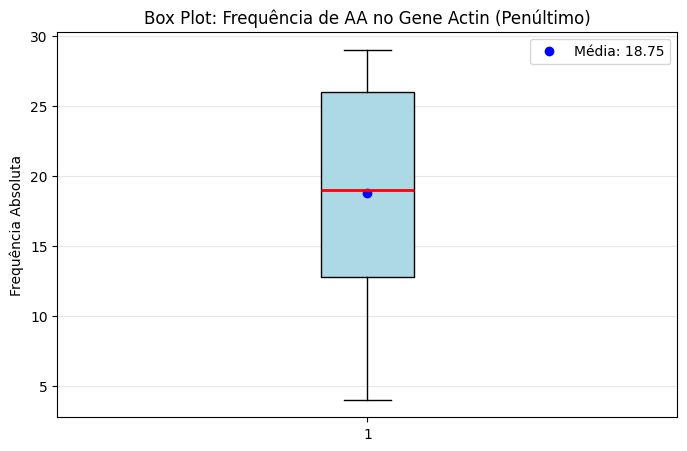

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def calcular_iqr(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna o Intervalo Interquartil (IQR).
    """
    s = pd.Series(sequencia_numerica)
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    return q3 - q1

# penúltimo gene (índice -2)
dados_actin = df_analise.iloc[-2]


plt.figure(figsize=(8, 5))
plt.boxplot(dados_actin, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2))

# Adicionando a média como um ponto
plt.plot(1, dados_actin.mean(), 'bo', label=f"Média: {dados_actin.mean()}")

plt.title('Box Plot: Frequência de AA no Gene Actin (Penúltimo)')
plt.ylabel('Frequência Absoluta')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [ ]:
import pandas as pd

def calcular_variancia_amostral(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna a variância amostral (n-1).
    """
    s = pd.Series(sequencia_numerica)
    
    return s.var()

# Variância da Prolina (Coluna 'P')
var_prolina = calcular_variancia_amostral(df_analise['P'])
print(f"Variância da Prolina: {var_prolina:.2f}")

# Variância do Terceiro Gene (Linha de índice 2)
var_terceiro_gene = calcular_variancia_amostral(df_analise.iloc[2])
print(f"Variância do terceiro gene: {var_terceiro_gene:.2f}")

Variância da Prolina: 118.50
Variância do terceiro gene: 7.92


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [16]:
import pandas as pd

def calcular_desvio_padrao(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna o desvio padrão amostral.
    """
    s = pd.Series(sequencia_numerica)
    return s.std()

# Desvio Padrão do Triptofano (Coluna 'W')
dp_triptofano = calcular_desvio_padrao(df_analise['W'])
print(f"Desvio Padrão do Triptofano: {dp_triptofano:.2f}")

# Desvio Padrão do último gene (Index -1)
dp_ultimo_gene = calcular_desvio_padrao(df_analise.iloc[-1])
print(f"Desvio Padrão do último gene: {dp_ultimo_gene:.2f}")

Desvio Padrão do Triptofano: 1.79
Desvio Padrão do último gene: 0.00


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [18]:
import pandas as pd

def calcular_cv(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna o Coeficiente de Variação (%).
    Trata casos onde a média é zero para evitar erro de divisão.
    """
    s = pd.Series(sequencia_numerica)
    media = s.mean()
    desvio = s.std()
    
    if media == 0:
        return 0.0
    
    return (desvio / media) * 100

# CV da Leucina (Coluna 'L')
cv_leucina = calcular_cv(df_analise['L'])
print(f"CV da Leucina: {cv_leucina:.2f}%")

# CV da Histona H2B (Index 1)
cv_h2b = calcular_cv(df_analise.iloc[1])
print(f"CV do gene de index 1: {cv_h2b:.2f}%")

CV da Leucina: 120.80%
CV do gene de index 1: 77.44%


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [ ]:
import pandas as pd
import numpy as np

def obter_medidas_resumo(sequencia_numerica):
    """
    Recebe um objeto unidimensional e retorna um dicionário com:
    Média, Mediana, Moda, Amplitude, Q1, Q3, IQR, Variância, 
    Desvio Padrão e Coeficiente de Variação.
    """
    s = pd.Series(sequencia_numerica)
    
    #Tendência Central e Posição
    media = s.mean()
    mediana = s.median()
    moda = s.mode()[0] if not s.mode().empty else np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    
    # Dispersão
    amplitude = s.max() - s.min()
    iqr = q3 - q1
    variancia = s.var()
    desvio_padrao = s.std()
    cv = (desvio_padrao / media * 100) if media != 0 else 0
    
    # Dicionário 
    medidas = {
        "Média": round(media, 2),
        "Mediana": round(mediana, 2),
        "Moda": round(moda, 2),
        "Amplitude": round(amplitude, 2),
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Variância": round(variancia, 2),
        "Desvio Padrão": round(desvio_padrao, 2),
        "CV (%)": round(cv, 2)
    }
    
    return medidas

resumo_f = obter_medidas_resumo(df_analise['F'])
print("Resumo Fenilalanina (F):")
for chave, valor in resumo_f.items():
    print(f"{chave}: {valor}")

    resumo_h2b = obter_medidas_resumo(df_analise.iloc[1])
print("\nResumo Histona H2B (Index 1):")
for chave, valor in resumo_h2b.items():
    print(f"{chave}: {valor}")

Resumo Fenilalanina (F):
Média: 8.0
Mediana: 2.0
Moda: 0
Amplitude: 25
Q1: 0.0
Q3: 13.0
IQR: 13.0
Variância: 119.5
Desvio Padrão: 10.93
CV (%): 136.65

Resumo Histona H2B (Index 1):
Média: 6.3
Mediana: 6.0
Moda: 3
Amplitude: 20
Q1: 3.0
Q3: 8.25
IQR: 5.25
Variância: 23.8
Desvio Padrão: 4.88
CV (%): 77.44


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

O gene com maior CV é 'cytochrome c oxidase subunit 1' com 152.16%.


C:\Users\mateu\AppData\Local\Temp\ipykernel_6680\118256504.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(df_para_plot.values,


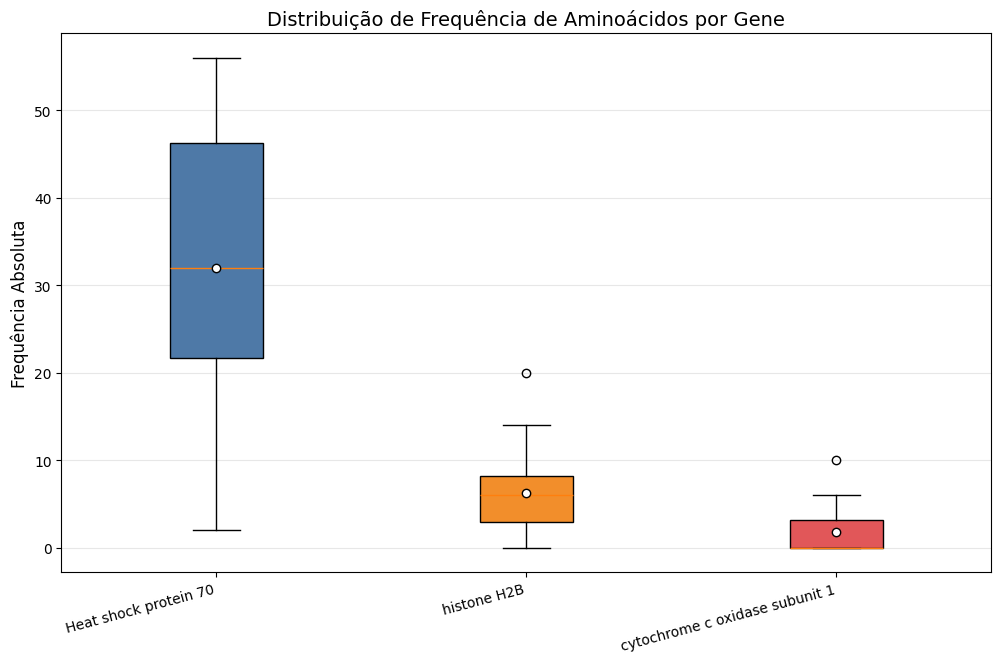

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def calcular_cv_series(s):
    """Auxiliar: Calcula o CV (%) de uma Series."""
    media = s.mean()
    desvio = s.std()
    if media == 0 or np.isnan(media) or np.isnan(desvio):
        return 0.0
    return (desvio / media) * 100

def gene_com_maior_cv(df):
    """
    Calcula o CV de cada gene (linha) e retorna o nome daquele com maior CV.
    Considera apenas as colunas de aminoácidos (as primeiras 20).
    """
    
    df_aa = df.iloc[:, :20]
    
    # CV para cada linha 
    cvs_genes = df_aa.apply(calcular_cv_series, axis=1)
    
    # índice  com o valor máximo
    gene_max_cv = cvs_genes.idxmax()
    max_cv_valor = cvs_genes.max()
    
    return gene_max_cv, max_cv_valor


nome_gene, valor_cv = gene_com_maior_cv(df_analise)
print(f"O gene com maior CV é '{nome_gene}' com {valor_cv:.2f}%.")



plt.figure(figsize=(12, 7))


df_para_plot = df_analise.iloc[:3, :20].T


bplot = plt.boxplot(df_para_plot.values, 
                    labels=df_para_plot.columns, 
                    patch_artist=True,
                    showmeans=True, 
                    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})


colors = ['#4e79a7', '#f28e2b', '#e15759']
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Distribuição de Frequência de Aminoácidos por Gene', fontsize=14)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.xticks(rotation=15, ha='right') # Rotacionar nomes para ler melhor
plt.grid(axis='y', alpha=0.3)

plt.show()

 O Coeficiente de Variação mede a dispersão relativa à média. No caso da COX, como a média é muito baixa (devido ao fragmento curto) e tem poucos aminoácidos dominantes, a razão $\frac{\text{Desvio Padrão}}{\text{Média}}$ é muito alta, resultando no maior CV e na aparência visual de maior desequilíbrio no Box Plot.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

O aminoácido com maior CV é 'N' com 150.25%.


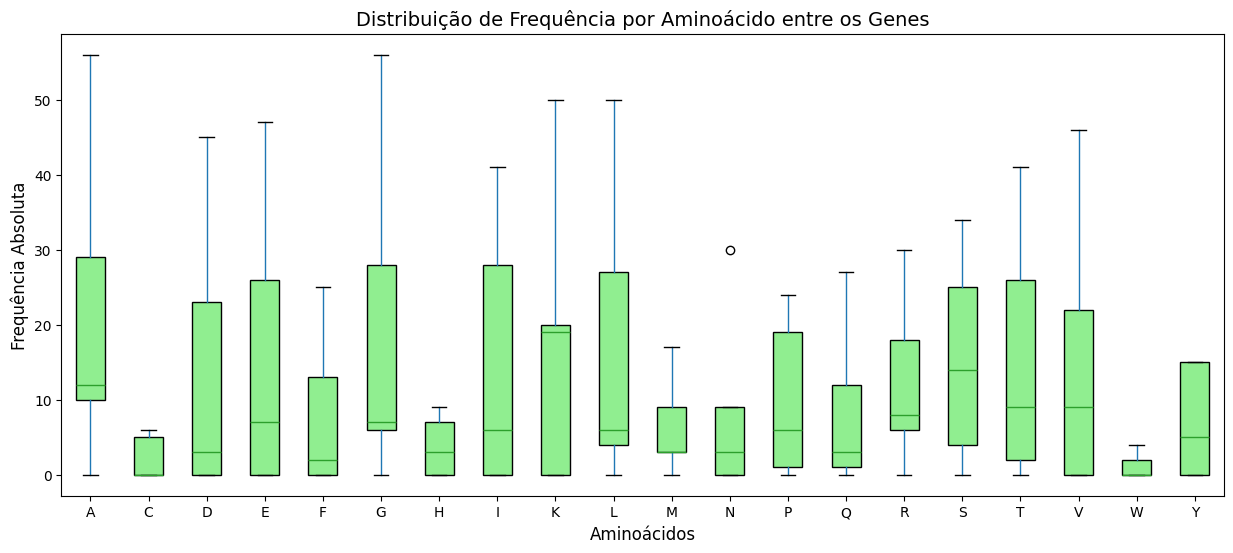

In [25]:
def aminoacido_maior_cv(df):
    """
    Calcula o CV para cada coluna (aminoácido) e retorna o nome 
    do aminoácido com a maior variabilidade relativa.
    """
   
    df_aa = df.iloc[:, :20]
    
    
    cvs_aminoacidos = df_aa.apply(calcular_cv_series, axis=0)
    
    maior_aa = cvs_aminoacidos.idxmax()
    maior_valor = cvs_aminoacidos.max()
    
    return maior_aa, maior_valor


nome_aa, valor_cv_aa = aminoacido_maior_cv(df_analise)
print(f"O aminoácido com maior CV é '{nome_aa}' com {valor_cv_aa:.2f}%.")

plt.figure(figsize=(15, 6))


df_analise.iloc[:, :20].boxplot(grid=False, patch_artist=True, 
                                 boxprops=dict(facecolor='lightgreen'))

plt.title('Distribuição de Frequência por Aminoácido entre os Genes', fontsize=14)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.xlabel('Aminoácidos', fontsize=12)
plt.show()

O Boxplot confirma que a distribuição dos aminoácidos  é altamente assimétrica . O alto CV é o reflexo numérico dessa "desigualdade" biológica entre uma proteína multifuncional grande (HSP70) e fragmentos curtos ou genes não proteicos (18S).